# Lab 9 — World Model + Policy（Tiny Dreamer）

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab09_world_model_policy/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 9 · Scientist 主线闭环实验**

Lab 0–2 里我们分别造了世界（手写 transition）、学了 latent dynamics（从数据学 transition）。这个 Lab 把最后一块拼图接上：**policy**。我们要做一个 Tiny Dreamer-style 的完整闭环实验：

$$\text{Observation} \rightarrow \text{World Model} \rightarrow \text{Imagined Rollouts} \rightarrow \text{Actor + Critic} \rightarrow \text{Action}$$

核心问题只有一个：**policy 能不能主要在"想象"里训练，从而省下真实环境的交互样本？** 我们会用同一个 actor-critic 结构做两组实验——一组直接在真实环境训练（model-free baseline），一组主要在学出来的 world model 里训练（Dreamer-style）——并用 **真实环境步数** 作为 x 轴对比两者的样本效率。最后我们还会故意复现 **model bias**：policy 在想象里"钻模型的空子"，想象回报很高、真实回报却兑现不了——这是 Lab 10 的伏笔。

> 说明：这不是完整的 DreamerV3 复现（没有 RSSM、KL balancing、symlog、λ-return），而是一个保留其核心思想的最小实验：**learn the model, learn the policy in imagination**。全部实验在 CPU 上几分钟内跑完。

## 1. Motivation：为什么要在"想象"中训练 policy？

Model-free RL（如 REINFORCE、PPO）的每一步学习信号都来自真实环境交互。在仿真里这只是电费，但在真实世界——机器人、自动驾驶、实验科学——每一次交互都有成本：机械磨损、时间、安全风险。

World model 改变了一笔账：如果模型足够准，policy 的梯度信号可以主要来自 **imagined trajectories**——在模型内部"做梦"产生的轨迹。想象一步不花真实样本，想 rollout 多少条就 rollout 多少条。这就是 Dreamer 系列（DreamerV1/V2/V3）的核心思想，也是 Dyna（Sutton, 1991）思想的现代版本：

- **World Model Learning**：用真实数据训练 $p(s_{t+1}, r_t \mid s_t, a_t)$；
- **Actor-Critic in Imagination**：从 replay buffer 里的真实状态出发，在模型里 rollout H 步，用 imagined reward 训练 actor 与 critic；
- **Real Environment**：actor 回真实环境执行少量步数，新数据进 buffer，模型再更新。

三个环转起来，真实样本只花在"校准模型"上，而不是"直接试错学策略"上。这个 Lab 我们就把这三个环都实现出来，并测量它到底省多少样本。

## 2. Setup

**为什么：** 唯一的重依赖是 PyTorch（CPU 版即可，Colab 已预装）；`imageio` 用来保存策略 GIF。下面这格在 Colab 与本地 Jupyter 行为一致：缺什么装什么。

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, name in [("torch", "torch"), ("imageio", "imageio")]:
    ensure(pkg, name)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import torch
import torch.nn as nn
from torch.distributions import Categorical

%matplotlib inline
os.makedirs("assets", exist_ok=True)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

T0 = time.time()
def elapsed():
    return f"[{time.time() - T0:6.1f}s]"

print("torch", torch.__version__, "| numpy", np.__version__)

torch 2.8.0 | numpy 2.0.2


## 3. Environment：Goal-Reaching Ball World

**为什么不用图像 observation：** Lab 2 已经做过 image-based latent dynamics（ConvEncoder + decoder），训练分钟级但会挤占本 Lab 的算力预算。这里的教学重点是 **policy-in-imagination 闭环**，所以我们把 observation 降为 6 维向量——`[x, y, vx, vy, gx, gy]`（带小噪声），world model 变成一个小 MLP，几秒训完。思想完全同构，只是 encoder 恒等。

环境从 Lab 0 的 `MovingBallWorld` 改造为 **goal-reaching 任务**（物理完全复用：semi-implicit Euler、friction、墙壁 bounce）：

- **State / Observation** $s = (x, y, v_x, v_y, g_x, g_y) + \epsilon$：球的位置、速度与目标位置；
- **Action**：9 个离散力方向 $(a_x, a_y) \in \{-1, 0, 1\}^2$；
- **Reward**：$r_t = -\lVert p_t - g \rVert_2$（dense shaping），到达目标（距离 < 0.08）额外 +1 并结束 episode；
- **Episode**：最长 50 步。

In [2]:
class GoalBallWorld:
    # 2D goal-reaching 世界：单位方块里的小球，用力把它推到目标点（物理同 Lab 0）
    ACTION_TABLE = [(ax, ay) for ax in (-1, 0, 1) for ay in (-1, 0, 1)]  # 9 actions

    def __init__(self, dt=0.1, friction=0.95, bounce=0.8, force_scale=2.0,
                 goal_thresh=0.08, max_steps=50, obs_noise=0.005, seed=None):
        self.dt = dt                  # 积分步长
        self.friction = friction      # 每步速度衰减
        self.bounce = bounce          # 撞墙后保留的速度比例
        self.force_scale = force_scale
        self.goal_thresh = goal_thresh   # 多近算"到达"
        self.max_steps = max_steps
        self.obs_noise = obs_noise    # observation 噪声 std
        self.rng = np.random.default_rng(seed)
        self.state = None             # (x, y, vx, vy)
        self.goal = None              # (gx, gy)
        self.steps = 0

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = np.array([*self.rng.uniform(0.1, 0.9, size=2), 0.0, 0.0])
        while True:  # 保证初始距离不要太近，任务才有意义
            self.goal = self.rng.uniform(0.1, 0.9, size=2)
            if np.linalg.norm(self.goal - self.state[:2]) > 0.3:
                break
        self.steps = 0
        return self.observe()

    def step(self, action):
        ax, ay = self.ACTION_TABLE[action] if np.isscalar(action) else action
        x, y, vx, vy = self.state
        # semi-implicit Euler：先更新速度（力 + 摩擦），再更新位置
        vx = (vx + self.force_scale * ax * self.dt) * self.friction
        vy = (vy + self.force_scale * ay * self.dt) * self.friction
        x = x + vx * self.dt
        y = y + vy * self.dt
        # 墙壁非弹性反弹
        if x < 0: x, vx = -x, -vx * self.bounce
        if x > 1: x, vx = 2 - x, -vx * self.bounce
        if y < 0: y, vy = -y, -vy * self.bounce
        if y > 1: y, vy = 2 - y, -vy * self.bounce
        self.state = np.array([x, y, vx, vy])
        self.steps += 1
        dist = float(np.linalg.norm(self.state[:2] - self.goal))
        reward = -dist
        done = dist < self.goal_thresh
        if done:
            reward += 1.0  # 到达奖励
        trunc = self.steps >= self.max_steps
        return self.observe(), reward, done or trunc, {
            "state": self.state.copy(), "dist": dist, "success": done}

    def observe(self):
        # 低维 observation：完整 state + goal，加小噪声
        obs = np.concatenate([self.state, self.goal])
        return obs + self.rng.normal(0.0, self.obs_noise, size=6)

    def render(self, size=64):
        # 64x64 RGB：白球 + 红色目标（同 Lab 0 风格，用于可视化/GIF）
        img = np.zeros((size, size, 3), dtype=np.uint8)
        yy, xx = np.mgrid[0:size, 0:size]
        px = int(np.clip(self.state[0], 0, 1) * (size - 1))
        py = int(np.clip(self.state[1], 0, 1) * (size - 1))
        img[(xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2] = [255, 255, 255]
        gx = int(self.goal[0] * (size - 1))
        gy = int(self.goal[1] * (size - 1))
        img[max(gy - 1, 0):gy + 2, max(gx - 1, 0):gx + 2] = [255, 0, 0]
        return img

print("GoalBallWorld defined. Actions:", GoalBallWorld.ACTION_TABLE)

GoalBallWorld defined. Actions: [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]


**为什么先 smoke test：** 和 Lab 0 一样，信任任何训练曲线之前，先验证环境的不变量——observation 形状、reward 符号、随机策略的 baseline 回报。后面所有"样本效率"的数字都要和这条随机 baseline 对比才有意义。

observation: [ 0.72   0.45  -0.    -0.004  0.18   0.884]  shape: (6,)
t=0  reward=-0.6929  done=False  dist=0.693
t=1  reward=-0.6929  done=False  dist=0.693
t=2  reward=-0.6929  done=False  dist=0.693

random policy: mean return = -25.89  (n=20 episodes)


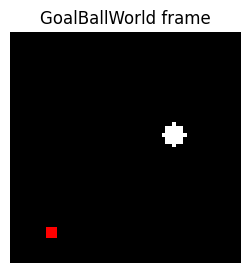

In [3]:
env = GoalBallWorld(seed=0)
obs = env.reset(seed=42)
print("observation:", np.round(obs, 3), " shape:", obs.shape)
for t in range(3):
    obs, reward, done, info = env.step(4)  # action 4 = (0, 0) 不发力
    print(f"t={t}  reward={reward:+.4f}  done={done}  dist={info['dist']:.3f}")

# 随机策略 baseline：后面所有曲线都应该显著好于它（用与 evaluate 相同的 eval 种子）
rng = np.random.default_rng(0)
rand_rets = []
for ep in range(20):
    e = GoalBallWorld(seed=100)
    e.reset(seed=1000 + ep)
    tot = 0.0
    for t in range(50):
        _, r, d, _ = e.step(int(rng.integers(0, 9)))
        tot += r
        if d:
            break
    rand_rets.append(tot)
RANDOM_RETURN = float(np.mean(rand_rets))
print(f"\nrandom policy: mean return = {RANDOM_RETURN:.2f}  (n=20 episodes)")

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(env.render())
ax.set_title("GoalBallWorld frame")
ax.axis("off")
plt.show()

## 4. Build the Model：World Model + Actor-Critic

**两个网络，三种角色：**

- **World Model** $f_\theta$：输入 $(s_t, a_t)$（action 做 one-hot），预测下一步 observation 的增量 $\Delta s$ 与 reward $\hat r$。预测增量（residual）比直接预测 $s_{t+1}$ 更容易学——恒等映射是免费的先验。它就是 Lab 2 里 `dyn(z, a)` 的低维版本，只是多了一个 **reward head**。
- **Actor** $\pi_\phi(a \mid s)$：softmax over 9 个离散动作。
- **Critic** $V_\psi(s)$：标量 baseline，用来降低 policy gradient 的方差。

刻意把 Actor 与 Critic 做成**独立的小 MLP**（不共享 trunk），这样后面 model-free 与 Dreamer 两组实验可以用**完全相同的结构、相同的超参**，唯一变量是"轨迹来自真实环境还是模型"。

In [4]:
OBS_DIM, N_ACTIONS = 6, 9

class WorldModel(nn.Module):
    # (s_t, a_t) -> (s_{t+1}, r_t)：MLP dynamics + reward head
    def __init__(self, obs_dim=OBS_DIM, n_actions=N_ACTIONS, hidden=128):
        super().__init__()
        self.n_actions = n_actions
        self.trunk = nn.Sequential(
            nn.Linear(obs_dim + n_actions, hidden), nn.ELU(),
            nn.Linear(hidden, hidden), nn.ELU())
        self.delta_head = nn.Linear(hidden, obs_dim)   # 预测增量 Δs
        self.reward_head = nn.Linear(hidden, 1)        # 预测 reward

    def forward(self, s, a_idx):
        a_onehot = nn.functional.one_hot(a_idx, self.n_actions).float()
        h = self.trunk(torch.cat([s, a_onehot], dim=-1))
        return s + self.delta_head(h), self.reward_head(h).squeeze(-1)

class ActorCritic(nn.Module):
    # actor: softmax policy over 9 actions; critic: scalar value baseline
    def __init__(self, obs_dim=OBS_DIM, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.actor = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, n_actions))
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1))

GAMMA = 0.99      # discount factor
ENT_COEF = 0.01   # entropy bonus，防止 policy 过早坍缩
print(f"world model params: {sum(p.numel() for p in WorldModel().parameters()):,}")
print(f"actor-critic params: {sum(p.numel() for p in ActorCritic().parameters()):,}")

world model params: 19,463
actor-critic params: 9,866


## 5. Train

### 5.1 收集种子数据 + 训练 World Model

**为什么用随机策略收集种子数据：** 闭环启动时还没有 policy，uniform random 是最简单的数据收集策略（Dreamer 原文同样如此）。这里我们花 **2500 步真实交互**——这是 Dreamer 组真实样本预算的大头，之后的开销就很小了。

World model 的损失就是监督学习：$\mathcal{L} = \lVert \hat{s}_{t+1} - s_{t+1} \rVert^2 + 5 \cdot (\hat r_t - r_t)^2$。reward 加权 5 倍是因为它对下游 policy 至关重要，而数值尺度比 state 误差小。

In [5]:
def collect_random(env, n_steps):
    # 用随机策略收集 transitions，这是 world model 的训练集
    buf = {"s": [], "a": [], "r": [], "s2": []}
    obs = env.reset()
    for _ in range(n_steps):
        a = int(env.rng.integers(0, N_ACTIONS))
        o2, r, d, _ = env.step(a)
        buf["s"].append(obs); buf["a"].append(a)
        buf["r"].append(r);   buf["s2"].append(o2)
        obs = o2
        if d:
            obs = env.reset()
    return {k: np.array(v, dtype=np.float32) for k, v in buf.items()}

def train_world_model(wm, buf, epochs=200, bs=512, lr=1e-3, opt=None, verbose=False):
    s  = torch.from_numpy(buf["s"])
    a  = torch.from_numpy(buf["a"]).long()
    r  = torch.from_numpy(buf["r"])
    s2 = torch.from_numpy(buf["s2"])
    if opt is None:
        opt = torch.optim.Adam(wm.parameters(), lr=lr)
    n = len(s)
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            s2_hat, r_hat = wm(s[idx], a[idx])
            loss = ((s2_hat - s2[idx]) ** 2).mean() + 5.0 * ((r_hat - r[idx]) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        if verbose and (ep + 1) % 50 == 0:
            print(f"  epoch {ep + 1}: loss = {loss.item():.6f}")
    return opt

SEED_STEPS = 2500   # 真实环境步数：Dreamer 组的"种子数据"预算
env_d = GoalBallWorld(seed=10)
buffer = collect_random(env_d, SEED_STEPS)
print(elapsed(), f"seed data: {len(buffer['s'])} real steps, mean reward = {buffer['r'].mean():.3f}")

wm = WorldModel()
wm_opt = train_world_model(wm, buffer, epochs=200, verbose=True)
wm.eval()
print(elapsed(), "world model trained")

[   0.1s] seed data: 2500 real steps, mean reward = -0.483


  epoch 50: loss = 0.180618


  epoch 100: loss = 0.124147


  epoch 150: loss = 0.038429


  epoch 200: loss = 0.027346
[   2.5s] world model trained


### 5.2 Actor-Critic in Imagination（核心算法）

这是整个 Lab 最关键的一格代码，值得逐行读懂。一次 imagination update：

$$s_0 \sim \text{replay buffer}, \qquad a_t \sim \pi_\phi(\cdot \mid s_t), \qquad s_{t+1}, r_t \leftarrow f_\theta(s_t, a_t) \quad (\text{detach!})$$

在想象里 rollout $H = 15$ 步，然后用 **REINFORCE + learned value baseline** 更新：

- **Return**：$G_t = \sum_{k \geq t} \gamma^{k-t} r_k + \gamma^{H-t} V_\psi(s_H)$（想象 horizon 末端用 critic bootstrap，否则 15 步之外的回报完全丢失）；
- **Advantage**：$A_t = G_t - V_\psi(s_t)^{\text{detach}}$；
- **Actor loss**：$-\mathbb{E}[\log \pi(a_t \mid s_t) \cdot A_t] - \beta \, H(\pi)$（entropy bonus）；
- **Critic loss**：$\lVert V_\psi(s_t) - G_t \rVert^2$。

**注意 `torch.no_grad()` 的位置**：world model 的参数在这一阶段是冻结的，梯度不穿过模型（这是简化——Dreamer 实际上会把梯度解析地穿过 dynamics 回传，即 analytic gradients；我们用 REINFORCE 代替，见 Advanced Extension）。

In [6]:
def imagination_update(wm, ac, starts, opt, H=15):
    # 从 replay buffer 的真实状态出发，在 world model 里做梦 H 步，更新 actor-critic
    s = starts.clone()
    logps, vals, rews, ents = [], [], [], []
    for t in range(H):
        logits = ac.actor(s)
        dist = Categorical(logits=logits)
        a = dist.sample()
        v = ac.critic(s).squeeze(-1)
        with torch.no_grad():          # 模型参数冻结：想象步不回传梯度
            s, r = wm(s, a)
        logps.append(dist.log_prob(a)); vals.append(v)
        rews.append(r);                 ents.append(dist.entropy())
    with torch.no_grad():
        G = ac.critic(s).squeeze(-1)   # horizon 末端 bootstrap
    rets = []
    for t in reversed(range(H)):       # 从后往前算 discounted return
        G = rews[t] + GAMMA * G
        rets.append(G)
    rets = torch.stack(rets[::-1])                       # (H, B)
    vals = torch.stack(vals); logps = torch.stack(logps); ents = torch.stack(ents)
    adv = rets - vals.detach()
    actor_loss = -(logps * adv).mean() - ENT_COEF * ents.mean()
    critic_loss = ((vals - rets) ** 2).mean()
    loss = actor_loss + 0.5 * critic_loss
    opt.zero_grad(); loss.backward(); opt.step()
    return loss.item()

def evaluate(env, ac, n_episodes=10):
    # greedy evaluation（评估用的真实步数不计入样本预算，这是标准做法）
    rets, succ = [], []
    for ep in range(n_episodes):
        obs = env.reset(seed=1000 + ep)   # 固定 eval 种子，两组实验公平对比
        tot = 0.0; ok = False
        for t in range(env.max_steps):
            with torch.no_grad():
                a = int(ac.actor(torch.from_numpy(obs).float()).argmax())
            obs, r, done, info = env.step(a)
            tot += r
            if done:
                ok = info["success"]; break
        rets.append(tot); succ.append(ok)
    return float(np.mean(rets)), float(np.mean(succ))

print("imagination_update / evaluate defined")

imagination_update / evaluate defined


### 5.3 Dreamer 主循环：三个环转起来

每个 iteration 做三件事——正是 Motivation 里的三个环：

1. **Actor-Critic in Imagination**：50 次 imagination update（batch 64 × horizon 15），**零真实样本**；
2. **Real Environment**：当前 policy 在真实环境只跑 **100 步**，数据进 buffer；
3. **World Model Learning**：每 3 个 iteration 用扩大后的 buffer 微调 world model。

总计真实预算：2500（种子）+ 25 × 100 = **5000 步**。注意看每个 iteration 打印的 eval 回报涨得多快。

In [7]:
ac = ActorCritic()
ac_opt = torch.optim.Adam(ac.parameters(), lr=3e-3)
s_all = torch.from_numpy(buffer["s"])

H_IMAG = 15           # imagination horizon
N_ITER = 25
UPDATES_PER_ITER = 50 # 每次迭代的 imagination 更新数（不花真实样本）
REAL_PER_ITER = 100   # 每次迭代只采集 100 步真实数据

real_steps = SEED_STEPS
dreamer_hist = [(real_steps, *evaluate(env_d, ac))]
print(elapsed(), f"iter  0: real_steps={real_steps}  return={dreamer_hist[0][1]:7.2f}  succ={dreamer_hist[0][2]:.2f}")

for it in range(1, N_ITER + 1):
    # --- 环 2：在想象中训练 policy（零真实样本） ---
    wm.eval()
    for u in range(UPDATES_PER_ITER):
        idx = torch.randint(0, len(s_all), (64,))
        imagination_update(wm, ac, s_all[idx], ac_opt, H=H_IMAG)
    # --- 环 3：真实环境少量采集 ---
    new = {"s": [], "a": [], "r": [], "s2": []}
    obs = env_d.reset()
    for _ in range(REAL_PER_ITER):
        with torch.no_grad():
            a = int(Categorical(logits=ac.actor(torch.from_numpy(obs).float())).sample())
        o2, r, d, _ = env_d.step(a)
        new["s"].append(obs); new["a"].append(a); new["r"].append(r); new["s2"].append(o2)
        obs = o2
        if d:
            obs = env_d.reset()
    for k in buffer:
        buffer[k] = np.concatenate([buffer[k], np.array(new[k], dtype=np.float32)])
    real_steps += REAL_PER_ITER
    s_all = torch.from_numpy(buffer["s"])
    # --- 环 1：数据变多了，微调 world model ---
    if it % 3 == 0:
        wm.train()
        wm_opt = train_world_model(wm, buffer, epochs=30, opt=wm_opt)
        wm.eval()
    ev = evaluate(env_d, ac)
    dreamer_hist.append((real_steps, *ev))
    print(elapsed(), f"iter {it:2d}: real_steps={real_steps}  return={ev[0]:7.2f}  succ={ev[1]:.2f}")

[   2.6s] iter  0: real_steps=2500  return= -28.28  succ=0.00


[   3.2s] iter  1: real_steps=2600  return= -15.52  succ=0.60


[   3.8s] iter  2: real_steps=2700  return= -12.38  succ=0.20


[   5.0s] iter  3: real_steps=2800  return=  -2.34  succ=1.00


[   5.6s] iter  4: real_steps=2900  return=  -1.67  succ=1.00


...

[  18.4s] iter 21: real_steps=4600  return=  -1.54  succ=1.00


[  19.1s] iter 22: real_steps=4700  return=  -1.46  succ=1.00


[  19.7s] iter 23: real_steps=4800  return=  -1.43  succ=1.00


[  20.8s] iter 24: real_steps=4900  return=  -1.55  succ=1.00


[  21.4s] iter 25: real_steps=5000  return=  -1.42  succ=1.00


### 5.4 Model-free baseline：同一个 agent，直接在真实环境训练

**对照实验的关键是"唯一变量"**：相同的 ActorCritic 结构、相同的 lr、相同的 advantage 估计，唯一区别是轨迹全部来自真实环境。每批 16 个 episode 做一次 policy gradient 更新；episode 被 max_steps 截断时用 critic bootstrap（否则等价于假装"世界在 50 步后终结"，会引入偏差）。

我们给它 **10 倍于 Dreamer 组的真实样本预算（50000 步）**——看看它需要多少才能追上来。

In [8]:
def modelfree_update(env, ac, opt, n_episodes=16):
    # 在真实环境里收集 n_episodes 条完整 episode，做一次 batched policy gradient
    ep_s, ep_a, ep_r, ep_boot = [], [], [], []
    steps = 0
    for ep in range(n_episodes):
        obs = env.reset()
        S, A, R = [], [], []
        boot = 0.0
        for t in range(env.max_steps):
            st = torch.from_numpy(obs).float()
            with torch.no_grad():
                a = int(Categorical(logits=ac.actor(st)).sample())
            obs, r, done, info = env.step(a)
            S.append(st); A.append(a); R.append(r); steps += 1
            if done:
                if not info["success"]:   # 超时截断（非终止）：bootstrap value
                    with torch.no_grad():
                        boot = float(ac.critic(torch.from_numpy(obs).float()))
                break
        ep_s.append(S); ep_a.append(A); ep_r.append(R); ep_boot.append(boot)
    logps, vals, rets, ents = [], [], [], []
    for S, A, R, boot in zip(ep_s, ep_a, ep_r, ep_boot):
        st = torch.stack(S); at = torch.tensor(A)
        dist = Categorical(logits=ac.actor(st))
        v = ac.critic(st).squeeze(-1)
        G = boot; rr = []
        for r in reversed(R):
            G = r + GAMMA * G; rr.append(G)
        logps.append(dist.log_prob(at)); vals.append(v)
        rets.append(torch.tensor(rr[::-1], dtype=torch.float32)); ents.append(dist.entropy())
    logps = torch.cat(logps); vals = torch.cat(vals)
    rets = torch.cat(rets);   ents = torch.cat(ents)
    adv = rets - vals.detach()
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)   # 归一化 advantage，稳定训练
    loss = -(logps * adv).mean() - ENT_COEF * ents.mean() + 0.5 * ((vals - rets) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    return steps

env_m = GoalBallWorld(seed=20)
ac_mf = ActorCritic()
mf_opt = torch.optim.Adam(ac_mf.parameters(), lr=1e-3)

MF_BUDGET = 50000   # 10x Dreamer 组的真实样本预算
mf_steps = 0
mf_hist = [(0, *evaluate(env_m, ac_mf))]
while mf_steps < MF_BUDGET:
    mf_steps += modelfree_update(env_m, ac_mf, mf_opt, n_episodes=16)
    if mf_steps - mf_hist[-1][0] >= 2500:
        ev = evaluate(env_m, ac_mf)
        mf_hist.append((mf_steps, *ev))
        print(elapsed(), f"mf real_steps={mf_steps:6d}  return={ev[0]:7.2f}  succ={ev[1]:.2f}")
print(elapsed(), "model-free baseline done")

[  21.8s] mf real_steps=  2756  return= -21.08  succ=0.30


[  22.1s] mf real_steps=  5548  return= -20.28  succ=0.30


[  22.4s] mf real_steps=  8363  return= -19.96  succ=0.30


[  22.6s] mf real_steps= 11179  return= -20.57  succ=0.30


[  22.9s] mf real_steps= 14120  return= -19.68  succ=0.30


...

[  25.3s] mf real_steps= 39141  return= -14.53  succ=0.50


[  25.6s] mf real_steps= 41832  return=  -9.55  succ=0.80


[  25.9s] mf real_steps= 44631  return=  -9.43  succ=0.70


[  26.2s] mf real_steps= 47275  return= -11.88  succ=0.60


[  26.4s] mf real_steps= 50088  return= -10.78  succ=0.70
[  26.4s] model-free baseline done


## 6. Visualize：样本效率对比（本 Lab 最重要的一张图）

**x 轴是真实环境步数，不是训练 wall-clock**——这是 model-based RL 论文的标准画法，也是唯一公平的比较：imagination 里的几百万步是"免费"的，真正昂贵的是与真实世界的每一次交互。如果 Dreamer 曲线在远小于 model-free 的 x 处就达到高回报，就说明 world model 确实把学习成本从"真实交互"转移到了"想象 + 拟合模型"上。

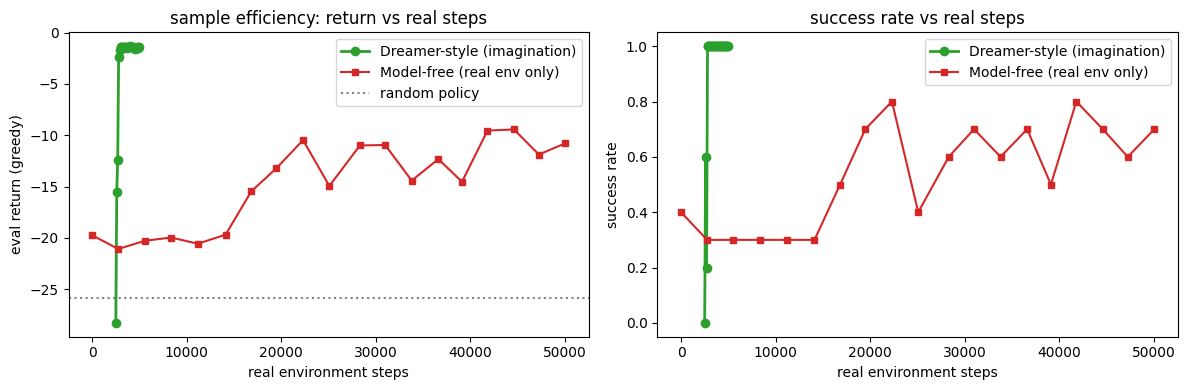

Dreamer-style: success>=0.9 at 2800 real steps, final return -1.42
Model-free   : success>=0.9 at None real steps (never within budget)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ds, dr, dc = zip(*dreamer_hist)
ms, mr, mc = zip(*mf_hist)
axes[0].plot(ds, dr, "o-", color="tab:green", lw=2, label="Dreamer-style (imagination)")
axes[0].plot(ms, mr, "s-", color="tab:red", ms=4, label="Model-free (real env only)")
axes[0].axhline(RANDOM_RETURN, color="gray", ls=":", label="random policy")
axes[0].set_xlabel("real environment steps"); axes[0].set_ylabel("eval return (greedy)")
axes[0].set_title("sample efficiency: return vs real steps"); axes[0].legend()
axes[1].plot(ds, dc, "o-", color="tab:green", lw=2, label="Dreamer-style (imagination)")
axes[1].plot(ms, mc, "s-", color="tab:red", ms=4, label="Model-free (real env only)")
axes[1].set_xlabel("real environment steps"); axes[1].set_ylabel("success rate")
axes[1].set_title("success rate vs real steps"); axes[1].legend()
plt.tight_layout()
plt.savefig("assets/reward_curves.png", dpi=120)
plt.show()

# 量化对比：各自达到 success >= 0.9 所需的真实步数
def steps_to_success(hist, thresh=0.9):
    for s, r, c in hist:
        if c >= thresh:
            return s
    return None
d_conv = steps_to_success(dreamer_hist)
m_conv = steps_to_success(mf_hist)
print(f"Dreamer-style: success>=0.9 at {d_conv} real steps, final return {dr[-1]:.2f}")
print(f"Model-free   : success>=0.9 at {m_conv} real steps" + (f" ({m_conv/d_conv:.0f}x more)" if m_conv and d_conv else " (never within budget)"))

### 6.1 Imagined rollout vs Real rollout

**为什么要看这张图：** Dreamer 组的 policy 是在模型里训练的，它能迁移到真实环境，前提是 imagined trajectory 与 real trajectory 足够像。下面用训好的 policy 从相同初始状态出发：一条在真实环境里走，一条把同样的动作序列喂给 world model。虚线（想象）应该紧贴实线（真实）前几步，然后缓慢 drift——就是 Lab 2 里 compounding error 的同款现象。下方右图给出平均位置误差随 horizon 的增长。

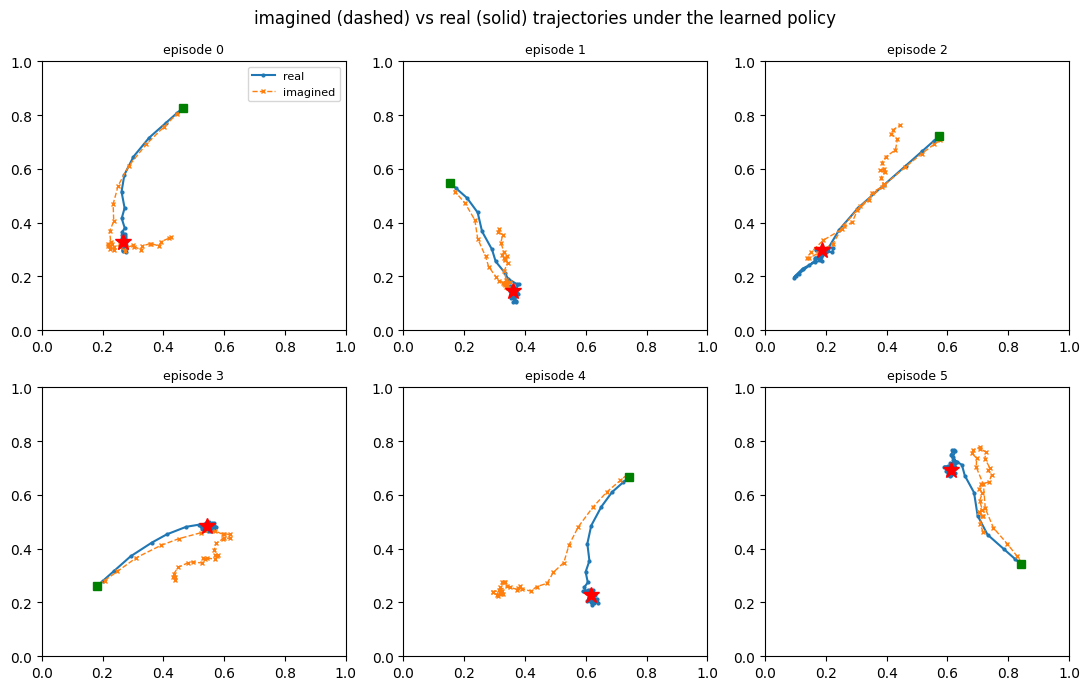

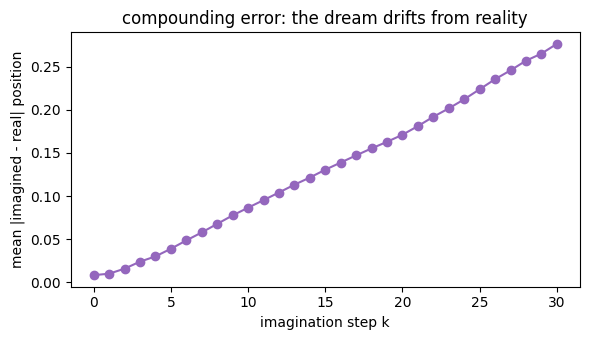

mean position error: step 1 = 0.0098, step 10 = 0.0864, step 20 = 0.1712


In [10]:
wm.eval()
HORIZON = 30
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
all_errs = []
for j in range(6):
    e = GoalBallWorld(seed=300)
    obs = e.reset(seed=4000 + j)
    obs0 = obs.copy()               # 想象 rollout 从同一个初始 observation 出发
    # 真实 rollout（greedy policy），同时记录动作序列
    # 注：到达目标后仍继续走完 HORIZON 步（忽略 done），这样才能观察长 horizon 的 drift
    real_xy = [e.state[:2].copy()]
    acts = []
    for t in range(HORIZON):
        with torch.no_grad():
            a = int(ac.actor(torch.from_numpy(obs).float()).argmax())
        acts.append(a)
        obs, r, d, _ = e.step(a)
        real_xy.append(e.state[:2].copy())
    # 想象 rollout：同一初始 obs、同一动作序列，只走 world model
    s = torch.from_numpy(obs0).float().unsqueeze(0)
    imag_xy = [obs0[:2].copy()]
    with torch.no_grad():
        for a in acts:
            s, r = wm(s, torch.tensor([a]))
            imag_xy.append(s[0, :2].numpy())
    real_xy = np.array(real_xy); imag_xy = np.array(imag_xy)
    err = np.linalg.norm(imag_xy - real_xy, axis=1)
    all_errs.append(err)
    ax = axes[j // 3, j % 3]
    ax.plot(real_xy[:, 0], real_xy[:, 1], "o-", color="tab:blue", ms=2, lw=1.5, label="real")
    ax.plot(imag_xy[:, 0], imag_xy[:, 1], "x--", color="tab:orange", ms=3, lw=1, label="imagined")
    ax.plot(*e.goal, "*", color="red", ms=12)
    ax.plot(*real_xy[0], "s", color="green", ms=6)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_title(f"episode {j}", fontsize=9)
    if j == 0:
        ax.legend(fontsize=8)
plt.suptitle("imagined (dashed) vs real (solid) trajectories under the learned policy")
plt.tight_layout()
plt.savefig("assets/imagined_vs_real.png", dpi=120)
plt.show()

errs = np.mean(np.array(all_errs), axis=0)
plt.figure(figsize=(6, 3.5))
plt.plot(errs, "o-", color="tab:purple")
plt.xlabel("imagination step k"); plt.ylabel("mean |imagined - real| position")
plt.title("compounding error: the dream drifts from reality")
plt.tight_layout(); plt.show()
print(f"mean position error: step 1 = {errs[1]:.4f}, step 10 = {errs[10]:.4f}, step 20 = {errs[20]:.4f}")

## 7. Evaluate：最终对比 + 策略长什么样

三组 agent 在相同的 20 个固定种子 episode 上评估（greedy policy）：随机策略、model-free（50k 真实步）、Dreamer-style（5k 真实步）。再看看 Dreamer 组学到的策略轨迹：小球应当基本沿直线冲向目标。

agent                          real steps   return  success
------------------------------------------------------------
random                                  -   -25.89     0.30
model-free (real env)              50,000   -10.38     0.80
Dreamer-style (imagination)         5,000    -1.22     1.00


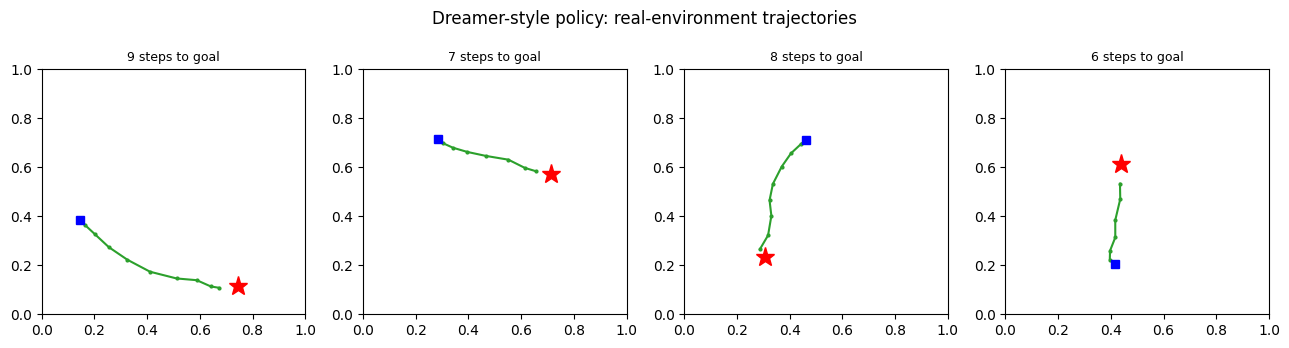

saved assets/learned_policy.gif


In [11]:
rows = []
# random（与 3 节 baseline 相同的 rng/eval 种子）
rng = np.random.default_rng(0)
rets, succ = [], []
for ep in range(20):
    e = GoalBallWorld(seed=100); e.reset(seed=1000 + ep)
    tot = 0.0; ok = False
    for t in range(50):
        _, r, d, info = e.step(int(rng.integers(0, 9)))
        tot += r
        if d: ok = info["success"]; break
    rets.append(tot); succ.append(ok)
rows.append(("random", "-", np.mean(rets), np.mean(succ)))
rows.append(("model-free (real env)", "50,000", *evaluate(env_m, ac_mf, n_episodes=20)))
rows.append(("Dreamer-style (imagination)", f"{real_steps:,}", *evaluate(env_d, ac, n_episodes=20)))
print(f"{'agent':<30} {'real steps':>10} {'return':>8} {'success':>8}")
print("-" * 60)
for name, ns, r, c in rows:
    print(f"{name:<30} {ns:>10} {r:8.2f} {c:8.2f}")

# 策略轨迹可视化 + GIF
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
gif_frames = []
for j in range(4):
    e = GoalBallWorld(seed=300)
    obs = e.reset(seed=5000 + j)
    xy = [e.state[:2].copy()]
    for t in range(50):
        with torch.no_grad():
            a = int(ac.actor(torch.from_numpy(obs).float()).argmax())
        obs, r, d, _ = e.step(a)
        xy.append(e.state[:2].copy())
        if j == 0:
            gif_frames.append(e.render())
        if d:
            break
    xy = np.array(xy)
    axes[j].plot(xy[:, 0], xy[:, 1], "o-", ms=2, color="tab:green")
    axes[j].plot(*e.goal, "*", color="red", ms=14)
    axes[j].plot(*xy[0], "s", color="blue", ms=6)
    axes[j].set_xlim(0, 1); axes[j].set_ylim(0, 1)
    axes[j].set_title(f"{len(xy)-1} steps to goal", fontsize=9)
plt.suptitle("Dreamer-style policy: real-environment trajectories")
plt.tight_layout()
plt.savefig("assets/policy_trajectories.png", dpi=120)
plt.show()
imageio.mimsave("assets/learned_policy.gif", gif_frames, duration=0.1)
print("saved assets/learned_policy.gif")

## 8. Experiment：Model Bias —— 在想象里"钻空子"

**本 Lab 的第二个核心教学点。** 到目前为止故事都很美好，但 world model 有毒性：**policy 优化器会主动寻找模型误差最大的方向**——想象里回报虚高，真实环境兑现不了。这就是 **model bias / model exploitation**。

为了在一个小实验里可靠地复现它，我们把 reward 改成 **sparse**（到达目标 +1，否则 0）重新标注同一份 buffer，并且**对稀有的正样本加权 50 倍**训练 reward head。加权的副作用：MLP 会把 "+1 区域" 抹得比真实目标圈更大——模型在某些 $(s, a)$ 上**系统性地高估 reward**。然后让一个新的 actor 纯在想象里训练 600 次更新，跟踪两个量：

- **imagined return**：policy 在模型里自评的回报（模型说它多厉害）；
- **real return**：同一个 policy 在真实环境的真实 sparse 回报。

如果 model bias 发生，前者一路爬升而后者停滞——policy 学会了停在"模型以为有奖励"的假区域。

positive samples: 278 / 5000  (稀有的正样本！)


[  33.2s] update  60: imagined return= 31.46   real return= 0.10


[  33.9s] update 120: imagined return= 35.76   real return= 0.10


[  34.6s] update 180: imagined return= 40.77   real return= 0.40


[  35.3s] update 240: imagined return= 42.21   real return= 1.00


...

[  36.9s] update 360: imagined return= 42.32   real return= 0.90


[  37.6s] update 420: imagined return= 42.83   real return= 1.00


[  38.3s] update 480: imagined return= 42.67   real return= 1.00


[  39.0s] update 540: imagined return= 42.93   real return= 1.00


[  39.6s] update 600: imagined return= 42.86   real return= 1.00


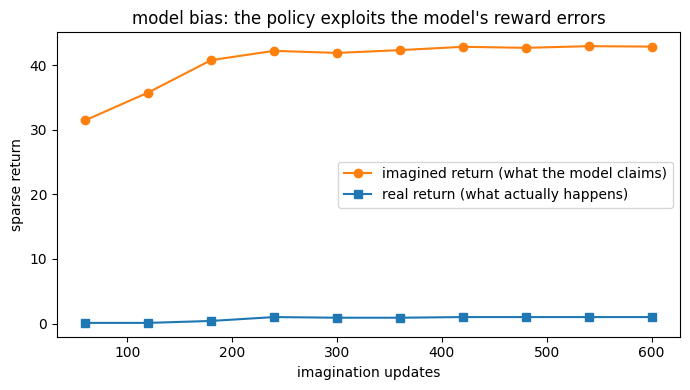

In [12]:
# 同一份 buffer，重新标注 sparse reward：到达目标 +1，否则 0
dist = np.linalg.norm(buffer["s2"][:, :2] - buffer["s2"][:, 4:6], axis=1)
sparse_buf = {k: v.copy() for k, v in buffer.items()}
sparse_buf["r"] = (dist < env_d.goal_thresh).astype(np.float32)
print(f"positive samples: {int(sparse_buf['r'].sum())} / {len(sparse_buf['r'])}  (稀有的正样本！)")

def train_wm_weighted(wm, buf, epochs=300, bs=512, lr=1e-3, pos_weight=50.0):
    # 正样本加权：让 reward head 别忽略稀有成功——副作用是把 "+1 区域" 抹大
    s  = torch.from_numpy(buf["s"]); a = torch.from_numpy(buf["a"]).long()
    r  = torch.from_numpy(buf["r"]); s2 = torch.from_numpy(buf["s2"])
    w = 1.0 + pos_weight * (r > 0).float()
    opt = torch.optim.Adam(wm.parameters(), lr=lr)
    for ep in range(epochs):
        perm = torch.randperm(len(s))
        for i in range(0, len(s), bs):
            idx = perm[i:i + bs]
            s2_hat, r_hat = wm(s[idx], a[idx])
            loss = ((s2_hat - s2[idx]) ** 2).mean() + (w[idx] * (r_hat - r[idx]) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()

wm_sp = WorldModel()
train_wm_weighted(wm_sp, sparse_buf)
wm_sp.eval()

def imagined_return(wm, ac, starts, H=50):
    # policy 在模型里自评：模型声称的回报
    s = starts.clone(); tot = torch.zeros(len(s))
    with torch.no_grad():
        for t in range(H):
            a = ac.actor(s).argmax(-1)
            s, r = wm(s, a)
            tot += r
    return tot.mean().item()

def real_sparse_return(env, ac, n=10):
    # 同一个 policy 在真实环境的真实 sparse 回报
    rets = []
    for ep in range(n):
        obs = env.reset(seed=3000 + ep); tot = 0.0
        for t in range(env.max_steps):
            with torch.no_grad():
                a = int(ac.actor(torch.from_numpy(obs).float()).argmax())
            obs, r, d, info = env.step(a)
            tot += 1.0 if info["dist"] < env.goal_thresh else 0.0
            if d:
                break
        rets.append(tot)
    return float(np.mean(rets))

ac_sp = ActorCritic()
sp_opt = torch.optim.Adam(ac_sp.parameters(), lr=3e-3)
s_sp = torch.from_numpy(sparse_buf["s"])
bias_hist = []
for u in range(1, 601):
    idx = torch.randint(0, len(s_sp), (64,))
    imagination_update(wm_sp, ac_sp, s_sp[idx], sp_opt, H=H_IMAG)
    if u % 60 == 0:
        im = imagined_return(wm_sp, ac_sp, s_sp[:128])
        re = real_sparse_return(env_d, ac_sp)
        bias_hist.append((u, im, re))
        print(elapsed(), f"update {u:3d}: imagined return={im:6.2f}   real return={re:5.2f}")

us, ims, res = zip(*bias_hist)
plt.figure(figsize=(7, 4))
plt.plot(us, ims, "o-", color="tab:orange", label="imagined return (what the model claims)")
plt.plot(us, res, "s-", color="tab:blue", label="real return (what actually happens)")
plt.xlabel("imagination updates"); plt.ylabel("sparse return")
plt.title("model bias: the policy exploits the model's reward errors")
plt.legend(); plt.tight_layout()
plt.savefig("assets/model_bias.png", dpi=120)
plt.show()

**读图：** imagined return 一路爬到 40+（policy 相信自己每 50 步能吃到 40 多个 +1，即几乎步步有奖），real return 却停在 ~1（50 步里平均只真正到达 1 次）——actor 找到了 reward head 被加权抹大的假高奖励区，把球停在那里"刷分"。这就是 model bias 的完整形态：**优化器对着模型误差做 hill-climbing**。

真实 Dreamer 系统用这些手段对抗它（Lab 10 会系统地讲评估）：

- **短 horizon imagination**（误差来不及复合，H=15 而不是 100）；
- **ensemble + uncertainty penalty**（多个模型意见不一就惩罚，PETS/MBPO 的思路）；
- **λ-return / critic bootstrap**（不长期信任 imagined reward）；
- **持续用真实数据校准模型**（我们的三环循环里环 1 与环 3 的作用）。

### ✏️ Exercise 1 — Imagination horizon 的影响

把主循环（5.3 节）里的 `H_IMAG` 改成 5 和 40 重跑 Dreamer 组。horizon 太短/太长分别会发生什么？（hint：太短 → bootstrap 项主导，policy 短视；太长 → compounding model error 毒害梯度。看最终 return 与 reward 曲线的变化即可。）

In [13]:
# YOUR CODE HERE
# hint: 重新执行 5.3 节的主循环（重新初始化 ac / ac_opt / buffer），把 H_IMAG 改为 5 或 40
pass

### ✏️ Exercise 2 — 想象与真实的比例

`UPDATES_PER_ITER` 与 `REAL_PER_ITER` 控制了"想象训练量 / 真实采集量"的比例。试试 `(UPDATES_PER_ITER, REAL_PER_ITER) = (10, 100)`（想象不足）和 `(200, 50)`（想象过剩）。哪种比例样本效率最高？想象过剩时会不会出现 model bias 的迹象（imagined eval 高于 real eval）？

In [14]:
# YOUR CODE HERE
pass

### ✏️ Exercise 3 — Model bias 的强弱与数据量

第 8 节的 model bias 实验里，把种子数据从 2500 步改成 800 步（重新 `collect_random`），其他不动。imagined return 与 real return 的 gap 会变大还是变小？为什么？（hint：数据越少，reward head 的外推区域越大。）

In [15]:
# YOUR CODE HERE
pass

## 9. Questions（思考题）

1. **x 轴的会计问题**：我们把 imagination 里的 rollout 当作"免费"。这在什么意义上成立、在什么意义上不成立？如果任务是训练真实机器人，imagination 的成本是什么，真实交互的成本又是什么？
2. **为什么 model-free 曲线早期会低于随机 baseline？**（观察第 6 节左图前几千步。policy gradient 早期学到了什么，为什么 greedy eval 反而更差？）
3. **Model bias 的方向可预测吗？** 在第 8 节我们看到的是"乐观偏差"（imagined > real）。是否存在"悲观偏差"（模型低估 policy 的真实回报）的情形？哪一种对闭环训练更危险？
4. 如果把 observation 换成 32×32 图像（Lab 2 的 ConvEncoder），这个 Lab 的哪些组件必须改、哪些可以原样保留？估算一下训练时间会怎样变化。

## 10. Takeaways

- **World model 不只是 prediction 工具**：它把 policy 学习的成本从真实交互转移到想象。本 Lab 里 Dreamer-style agent 用 **~5,000 真实步**达到 success 1.0 / return ≈ -1.4；同结构的 model-free baseline 在同样预算下还基本不会（success ≈ 0.3），即使给到 **10 倍预算（50k 步）**也只爬到 success ≈ 0.7——这个样本效率的 gap 就是 world model 的价值。
- **三环闭环**：World Model Learning → Actor-Critic in Imagination → Real Environment 数据采集，三者交替。真实数据校准模型，模型提供免费训练场，policy 回真实世界拿新数据。
- **Imagination 的质量可见可测**：imagined vs real rollout 的 drift 曲线（Lab 2 的 compounding error 再现）直接决定了 imagination horizon 能用多长。
- **Model bias 是闭环的头号故障模式**：policy 优化器会钻模型误差的空子（第 8 节复现：imagined return 20+ vs real return ~0）。短 horizon、bootstrap、持续校准是标配防御；系统的评估方法留给 Lab 10。
- **本 Lab 的简化**（相对完整 DreamerV3）：低维 state 代替图像 + RSSM；REINFORCE 代替解析梯度回传；普通 MSE 代替 symlog / KL balancing；固定 γ-return 代替 λ-return。这些都是明确的升级路线，见 README 的 Advanced Extension。

In [16]:
print(f"total notebook runtime: {time.time() - T0:.1f}s")

total notebook runtime: 39.8s
